In [1]:
# from NNCalderon_rutine_uneven_sampling import *
from NNCalderon_rutine_summing_gamma import *

In [2]:
###### Choose the cases for the conductivity gamma to be solved, and the folder with the desidered BCs #######

# CASES = ["single_inclusion", "multiple_inclusions", "checkerboard"]
# CASES = ["gaussian_inclusion"]
# CASES = ["fourierboard"]
CASES = ["checkerboard"]


NOISE_LEVELS = {
    "0pct": 0.0,
    # "1pct": 0.01,
    # "5pct": 0.05
}

for case in CASES:
    for noise_str, noise_val in NOISE_LEVELS.items():
        # print("\n" + "="*60)
        # # print("RUNNING EXPERIMENT: CASE=" + case + ", NOISE=" + noise_str)
        # print("="*60 + "\n")

        current_dir = f'{os.getcwd()}'
        data_filepath = os.path.join(f"{current_dir}", "data_checkerboard_50_BC_20_trig_30_wavelets", "dtn_data_" + case + ".npz")
        print(data_filepath)

/Users/pablo/Documents/GitHub/NNCalderon/Nyx/data_checkerboard_50_BC_20_trig_30_wavelets/dtn_data_checkerboard.npz


In [3]:

### Choose saving path: e.g. same path where data is ###
# saving_path = os.path.dirname(data_filepath) + '/test_1'
saving_path = '/Users/pablo/Desktop/Calderon_Problem/NNCalderon/Nyx/local_tests/' + 'checkerboard_summing_gamma_test_1'
print(saving_path)


/Users/pablo/Desktop/Calderon_Problem/NNCalderon/Nyx/local_tests/checkerboard_summing_gamma_test_1


In [4]:
dataset = CalderonDataset(data_filepath, noise_val)

print('grid size', dataset.grid_N)
print('number of BC functions', dataset.k_indices.shape[0])



grid size 64
number of BC functions 62


In [5]:
#### Choose the architecture and hyperparameters for the pinn training ###

CONFIG = {
    'epochs': 1000,
    'learning_rate': 5e-4,
    'lr_decay_gamma': 0.95,
    'lr_decay_step': 2000,
    'batch_size_pde': 4096,
    'batch_size_bnd': 1024,
    'ffe_mapping_size': 256,
    'ffe_scale': 10.0,
    'gamma_net_layers': 4,
    'gamma_net_neurons': 128,
    'u_net_layers': 6,
    'u_net_neurons': 256,
    'loss_weights': {'pde': 1.0, 'dirichlet_bc': 10.0, 'neumann_bc': 10.0, 'force_true_gamma': 0.0},
    'density_factor': 10.0,
    'center_bounds': (0.2, 0.8),
    'sampling_method': 'uniform',  # 'linear_dense_center', 'square_dense_center'

}


In [6]:
### Initialize the Trainer/Solver ###

trainer = Trainer(CONFIG, num_bcs=dataset.num_bcs, synthetic_data=data_filepath, saving_path=saving_path,\
                  gamma_activ = nn.ReLU(), gamma_actv_last_layer = True)



Saving directory created: /Users/pablo/Desktop/Calderon_Problem/NNCalderon/Nyx/local_tests/checkerboard_summing_gamma_test_1
Checking if local GPUs are available
True
Using device: mps


In [7]:
trainer.update_optimizer()

Current LR is: 0.0005


In [10]:
epochs = 1000

trainer.train(dataset, case, noise_str, train_epochs=epochs, disable_progress_bar=False)


Starting training for case: checkerboard, noise: 0pct


Training epochs:   0%|          | 1/1000 [00:02<40:08,  2.41s/it]


KeyboardInterrupt: 

In [9]:
### Save and Visualize results ###
# trainer.save_model(path=f'{saving_path}/NN')

In [1]:
trainer.plot_loss(save_fig=False)


NameError: name 'trainer' is not defined

In [19]:
data = np.load(trainer.synthetic_data)

In [2]:
N = 128

gamma_nn = trainer.predict_gamma(N=N)

# 1D coordinates
x = torch.linspace(0, 1, N)
y = torch.linspace(0, 1, N)

# 2D meshgrid
X, Y = torch.meshgrid(x, y, indexing="ij")  # shape (N, N)

# Stack into (N*N, 2) list of coordinates
xy_grid = torch.stack([X.flatten(), Y.flatten()], dim=-1)
gamma_true = load_gamma_interpolator(data['gamma_true'])(xy_grid).reshape(N,N).cpu().detach().numpy()

eps = 1e-12
# rel_error = np.abs((gamma_true - gamma_nn) / (gamma_true + eps))
rel_error = np.log10(np.abs((gamma_true - gamma_nn) / (gamma_true + eps)))

mean_rel_error = np.mean(10**rel_error)
print('Mean Relative error:', mean_rel_error*100, '%')

print(gamma_nn.shape)

fig,ax = plt.subplots(1,3,figsize=(15,4))
im0 = ax[0].imshow(gamma_nn, origin='lower', extent=[0, 1, 0, 1], cmap="viridis")
fig.colorbar(im0, ax=ax[0], label=r"NN $\gamma(x,y)$")
ax[0].set_title(r"$\gamma^{NN}(x,y)$")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")

im1 = ax[1].imshow(gamma_true, origin='lower', extent=[0, 1, 0, 1], cmap="viridis")
fig.colorbar(im1, ax=ax[1], label=r"True $\gamma(x,y)$")
ax[1].set_title(r"True $\gamma(x,y)$")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")

im2 = ax[2].imshow(rel_error, origin='lower', extent=[0, 1, 0, 1], cmap="viridis")
fig.colorbar(im2, ax=ax[2], label=r"Log(rel error)")
ax[2].set_title(r"Mean RE=" + f"{mean_rel_error*100:.2f}%")
ax[2].set_xlabel("x")
ax[2].set_ylabel("y")

plt.tight_layout()
plt.show()
# fig.savefig(f'{saving_path}/gamma_recovered_epoch_{len(DE_loss)}.pdf')



NameError: name 'trainer' is not defined

Mean Relative error: 71.46432995796204 %
(128, 128)


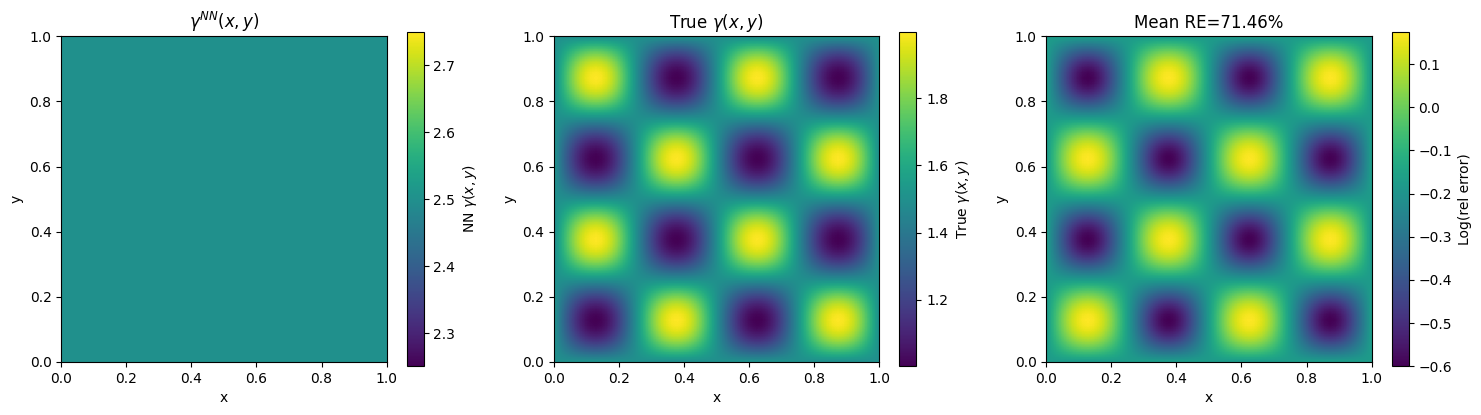

In [13]:
trainer.plot_gamma_nn(save_fig=False)

In [ ]:
trainer.plot_boundary_data(dataset=dataset, save_fig=None, show_fig=[0,10,20])


In [ ]:
trainer.plot_induced_potential_u(save_fig=None, show_fig=[0,10,20])


In [ ]:
trainer.plot_residuals(save_fig=None, show_fig=[0,10,20])
